# Assignment 03 — Diabetes: Traditional ML vs 5-Layer Deep Learning

## Dataset
**Pima Indians Diabetes Dataset** (`diabetes_dataset.csv`)

## Experimental goal
Train and compare:

1. **Logistic Regression**
2. **K-Nearest Neighbors (KNN)**
3. **Random Forest**
4. **5-layer Multi-Layer Perceptron (MLP)** with PyTorch

The notebook is designed so that all four final models are evaluated on the **same held-out test set**.

### Main comparison metrics
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

### Deep Learning analysis
- Architecture and tensor shapes
- Number of trainable parameters
- Forward propagation
- ReLU and Sigmoid
- Binary Cross-Entropy loss
- Backpropagation and Gradient Descent
- Training / validation loss curves
- Training / validation accuracy curves
- Learned representation
- Training cost and generalization

> **Teacher-material alignment:** the mathematical blocks below follow the terminology and formulas used in the provided *Deep Learning from Scratch with NumPy* and *Assignment 03: Neural Networks and Representation Learning* slides. The implementation uses PyTorch for the 5-layer MLP, matching the Assignment 03 PyTorch training-cycle material.

# 1. Experimental Design

To make the comparison scientifically meaningful:

- Use one common **Train / Validation / Test** split: 70% / 15% / 15%.
- Preserve class ratios with `stratify`.
- Fit preprocessing only on training data during model development.
- Use validation data to select **K for KNN** and **best epoch for MLP**.
- After hyperparameters are fixed, combine Train + Validation and retrain all four final models.
- Use the Test set **once** for final comparison.

This gives the final models the same amount of training data and keeps the test set untouched during model selection.

# 2. Import Libraries

In [1]:
import os
import copy
import random
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader


## 2.1 Reproducibility

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)

Device: cpu
PyTorch: 2.14.0+cpu


# 3. Load and Inspect the Dataset

In [3]:
candidate_paths = [
    "diabetes_dataset.csv",
    "/mnt/data/diabetes_dataset.csv"
]

DATA_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError("Place diabetes_dataset.csv in the same folder as this notebook.")

df = pd.read_csv(DATA_PATH)
print("Path :", DATA_PATH)
print("Shape:", df.shape)
df.head()

Path : diabetes_dataset.csv
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df["Outcome"].value_counts().sort_index())
print("\nTarget ratio:")
print(df["Outcome"].value_counts(normalize=True).sort_index().round(4))

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Missing values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Target ratio:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [5]:
zero_check_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Zero-value check:")
for col in zero_check_columns:
    if col in df.columns:
        print(f"{col:15s}: {(df[col] == 0).sum()}")

Zero-value check:
Glucose        : 0
BloodPressure  : 0
SkinThickness  : 0
Insulin        : 0
BMI            : 0


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.677083,30.464161,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.389323,12.106039,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,29.089844,8.890820,7.000,25.00000,28.0000,32.00000,99.00
Insulin,768.0,141.753906,89.100847,14.000,102.50000,102.5000,169.50000,846.00
BMI,768.0,32.434635,6.880498,18.200,27.50000,32.0500,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


# 4. Exploratory Data Analysis (EDA)

These figures can be reused in the report as dataset-description visualizations.

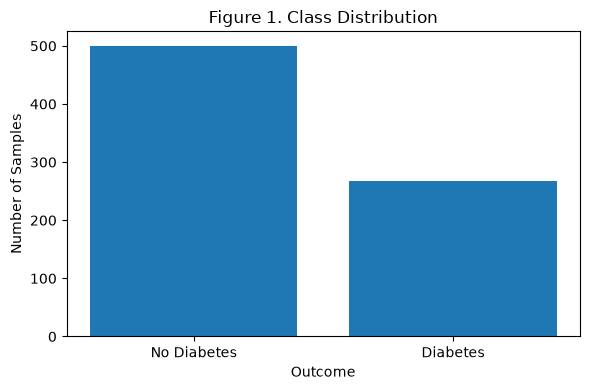

In [7]:
class_counts = df["Outcome"].value_counts().sort_index()
plt.figure(figsize=(6,4))
plt.bar(["No Diabetes", "Diabetes"], class_counts.values)
plt.title("Figure 1. Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

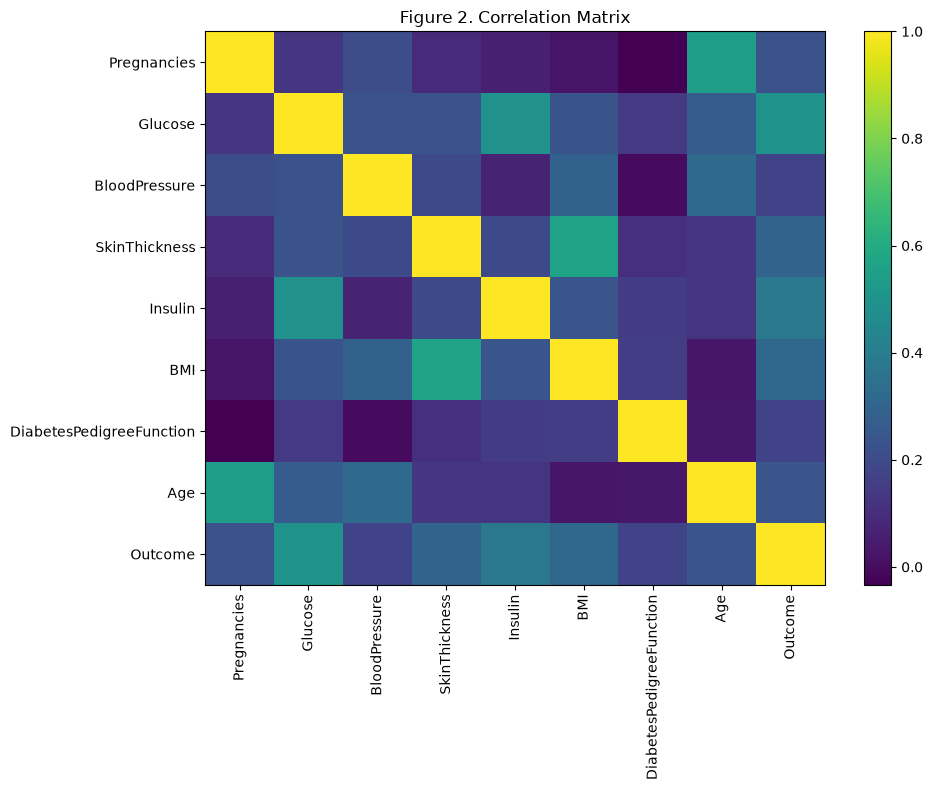

In [8]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Figure 2. Correlation Matrix")
plt.tight_layout()
plt.show()

# 5. Preprocessing and Mathematical Reference

## 5.1 Standardization

The provided *Deep Learning from Scratch* material standardizes each input feature as:

$$
\boxed{x' = \frac{x-\mu}{\sigma}}
$$

where $\mu$ and $\sigma$ are calculated from the **training data**.

For the report, this formula corresponds directly to the preprocessing step below. The same learned mean and standard deviation are then used for validation and test data to avoid information leakage.

In [9]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train     :", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test      :", X_test.shape, y_test.shape)

Train     : (537, 8) (537,)
Validation: (115, 8) (115,)
Test      : (116, 8) (116,)


In [10]:
scaler_dev = StandardScaler()
X_train_scaled = scaler_dev.fit_transform(X_train)
X_val_scaled = scaler_dev.transform(X_val)
X_test_scaled_dev = scaler_dev.transform(X_test)

print("Training means after scaling:", np.round(X_train_scaled.mean(axis=0), 4))
print("Training stds after scaling :", np.round(X_train_scaled.std(axis=0), 4))

Training means after scaling: [ 0. -0.  0.  0.  0.  0.  0. -0.]
Training stds after scaling : [1. 1. 1. 1. 1. 1. 1. 1.]


# 6. Common Evaluation Functions

In [11]:
def classification_metrics(model_name, y_true, y_pred, y_prob):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }


def timed_predict(model, X_input):
    start = time.perf_counter()
    pred = model.predict(X_input)
    elapsed_ms = (time.perf_counter() - start) * 1000
    return pred, elapsed_ms

# 7. Traditional Machine Learning Models

The traditional ML pipeline uses prepared input features directly:

$$
\boxed{X \rightarrow \text{ML Algorithm} \rightarrow \hat{y}}
$$

We train three different families of ML models so that the comparison is not limited to one modeling assumption.

## 7.1 Model 1 — Logistic Regression

A linear probabilistic baseline for binary classification. It uses standardized features.

In [12]:
logistic_dev = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
logistic_dev.fit(X_train_scaled, y_train)

lr_val_pred = logistic_dev.predict(X_val_scaled)
lr_val_prob = logistic_dev.predict_proba(X_val_scaled)[:,1]
classification_metrics("Logistic Regression", y_val, lr_val_pred, lr_val_prob)

{'Model': 'Logistic Regression',
 'Accuracy': 0.6956521739130435,
 'Precision': 0.5641025641025641,
 'Recall': 0.55,
 'F1': 0.5569620253164557,
 'ROC_AUC': 0.8046666666666665}

## 7.2 Model 2 — K-Nearest Neighbors (KNN)

KNN is distance-based, therefore standardization is important. We choose `k` using the validation set only.

In [13]:
k_candidates = [3, 5, 7, 9, 11]
knn_val_rows = []

for k in k_candidates:
    m = KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_val_scaled)
    prob = m.predict_proba(X_val_scaled)[:,1]
    row = classification_metrics(f"KNN (k={k})", y_val, pred, prob)
    row["k"] = k
    knn_val_rows.append(row)

knn_validation = pd.DataFrame(knn_val_rows).sort_values(["F1", "ROC_AUC"], ascending=False)
knn_validation.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,k
2,KNN (k=7),0.8435,0.7391,0.850,0.7907,0.9005,7
1,KNN (k=5),0.8087,0.7045,0.775,0.7381,0.8840,5
4,KNN (k=11),0.8000,0.6809,0.800,0.7356,0.8777,11
3,KNN (k=9),0.7913,0.6818,0.750,0.7143,0.8753,9
0,KNN (k=3),0.7739,0.6591,0.725,0.6905,0.8568,3


In [14]:
BEST_K = int(knn_validation.iloc[0]["k"])
print("Selected k =", BEST_K)

Selected k = 7


## 7.3 Model 3 — Random Forest

Random Forest is a nonlinear ensemble of decision trees. It is trained on the original feature scale because tree splits do not require standardization.

In [15]:
rf_dev = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)
rf_dev.fit(X_train, y_train)

rf_val_pred = rf_dev.predict(X_val)
rf_val_prob = rf_dev.predict_proba(X_val)[:,1]
classification_metrics("Random Forest", y_val, rf_val_pred, rf_val_prob)

{'Model': 'Random Forest',
 'Accuracy': 0.8173913043478261,
 'Precision': 0.7209302325581395,
 'Recall': 0.775,
 'F1': 0.7469879518072289,
 'ROC_AUC': 0.9278333333333333}

# 8. Deep Learning Theory — Formula Blocks for the Report

The teacher material describes Deep Learning as a **composition of learned transformations**:

$$
\boxed{\hat{y} = f_5(f_4(f_3(f_2(f_1(X)))))}
$$

For this assignment we extend the slide's 3-trainable-layer diabetes network into a **5-trainable-layer MLP**:

$$
\boxed{8 \rightarrow 64 \rightarrow 32 \rightarrow 16 \rightarrow 8 \rightarrow 1}
$$

The four hidden layers learn intermediate representations before the output layer produces the final score.

## 8.1 Neuron and Linear Transformation

The teacher slides describe a neuron as:

$$
\boxed{z = w^T x + b}
$$

followed by an activation:

$$
\boxed{h = \phi(z)}
$$

For a complete layer with a batch of observations:

$$
\boxed{Z = XW + b}
$$

The weight matrix changes the representation dimension; the activation function introduces nonlinearity.

## 8.2 ReLU Activation

The teacher material uses Rectified Linear Unit:

$$
\boxed{ReLU(z)=\max(0,z)}
$$

or equivalently:

$$
ReLU(z)=
\begin{cases}
0, & z < 0 \\
z, & z \geq 0
\end{cases}
$$

Without nonlinear activation functions, stacking linear layers would still collapse into one overall linear-affine transformation.

## 8.3 Five-Layer Forward Propagation

For this 5-layer network:

$$
\boxed{H_1 = ReLU(XW_1+b_1)}
$$

$$
\boxed{H_2 = ReLU(H_1W_2+b_2)}
$$

$$
\boxed{H_3 = ReLU(H_2W_3+b_3)}
$$

$$
\boxed{H_4 = ReLU(H_3W_4+b_4)}
$$

$$
\boxed{Z_5 = H_4W_5+b_5}
$$

For probability interpretation in binary classification:

$$
\boxed{\hat{y}=\sigma(Z_5)=\frac{1}{1+e^{-Z_5}}}
$$

Decision rule:

$$
\hat{y}\geq0.5 \Rightarrow Diabetes,\qquad \hat{y}<0.5 \Rightarrow No\ Diabetes
$$

## 8.4 Binary Cross-Entropy Loss

The *Deep Learning from Scratch* material uses Binary Cross-Entropy for diabetes classification:

$$
\boxed{
L=-\frac{1}{N}\sum_{i=1}^{N}
\left[y_i\log(\hat{y}_i)+(1-y_i)\log(1-\hat{y}_i)\right]
}
$$

The loss answers: **How bad are the current predictions?**

In PyTorch we use `BCEWithLogitsLoss`, which accepts the raw output logit and combines the sigmoid/BCE computation in a numerically stable implementation.

## 8.5 Backpropagation and Gradient Descent

The teacher material summarizes the learning cycle as:

$$
\boxed{Forward \rightarrow Loss \rightarrow Backward \rightarrow Update}
$$

Backpropagation applies the chain rule to compute gradients. Conceptually:

$$
\boxed{
\frac{\partial L}{\partial W_1}
=
\frac{\partial L}{\partial H_1}
\frac{\partial H_1}{\partial Z_1}
\frac{\partial Z_1}{\partial W_1}
}
$$

Gradient descent updates a parameter $\theta$ by:

$$
\boxed{\theta_{t+1}=\theta_t-\eta\nabla_{\theta}L}
$$

where $\eta$ is the learning rate.

# 9. Build the 5-Layer MLP in PyTorch

In [16]:
class FiveLayerMLP(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)  # Layer 1
        self.fc2 = nn.Linear(64, 32)         # Layer 2
        self.fc3 = nn.Linear(32, 16)         # Layer 3
        self.fc4 = nn.Linear(16, 8)          # Layer 4
        self.fc5 = nn.Linear(8, 1)           # Layer 5
        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2))
        h4 = self.relu(self.fc4(h3))
        logits = self.fc5(h4)
        return logits

    def representation(self, x):
        h1 = self.relu(self.fc1(x))
        h2 = self.relu(self.fc2(h1))
        h3 = self.relu(self.fc3(h2))
        h4 = self.relu(self.fc4(h3))
        return h4

## 9.1 Tensor Shapes

With batch size $B$:

| Stage | Tensor shape |
|---|---|
| Input | $B\times8$ |
| Layer 1 | $B\times64$ |
| Layer 2 | $B\times32$ |
| Layer 3 | $B\times16$ |
| Layer 4 | $B\times8$ |
| Layer 5 | $B\times1$ |

This follows the teacher slide's **Batch Dimension × Feature Dimension** interpretation.

In [17]:
dev_mlp = FiveLayerMLP(input_dim=X_train.shape[1]).to(DEVICE)
print(dev_mlp)

total_params = sum(p.numel() for p in dev_mlp.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

param_rows = []
for name, p in dev_mlp.named_parameters():
    param_rows.append({"Parameter": name, "Shape": str(tuple(p.shape)), "Count": p.numel()})
pd.DataFrame(param_rows)

FiveLayerMLP(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)
Total trainable parameters: 3329


,Parameter,Shape,Count
0,fc1.weight,"(64, 8)",512
1,fc1.bias,"(64,)",64
2,fc2.weight,"(32, 64)",2048
3,fc2.bias,"(32,)",32
4,fc3.weight,"(16, 32)",512
5,fc3.bias,"(16,)",16
6,fc4.weight,"(8, 16)",128
7,fc4.bias,"(8,)",8
8,fc5.weight,"(1, 8)",8
9,fc5.bias,"(1,)",1


### Parameter-count formula

For `Linear(in, out)`:

$$
\boxed{\#parameters = in\times out + out}
$$

For the chosen architecture:

$$
(8\times64+64)+(64\times32+32)+(32\times16+16)+(16\times8+8)+(8\times1+1)=\boxed{3329}
$$

# 10. PyTorch Dataset and DataLoader

In [18]:
def make_tensor_dataset(X_array, y_series):
    X_tensor = torch.tensor(np.asarray(X_array), dtype=torch.float32)
    y_tensor = torch.tensor(np.asarray(y_series).reshape(-1,1), dtype=torch.float32)
    return TensorDataset(X_tensor, y_tensor)

BATCH_SIZE = 32
train_ds = make_tensor_dataset(X_train_scaled, y_train)
val_ds = make_tensor_dataset(X_val_scaled, y_val)

g = torch.Generator()
g.manual_seed(RANDOM_STATE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
print("One input batch :", xb.shape)
print("One target batch:", yb.shape)

One input batch : torch.Size([32, 8])
One target batch: torch.Size([32, 1])


The Assignment 03 material distinguishes:

- `Dataset`: provides individual samples.
- `DataLoader`: organizes samples into mini-batches.

Mini-batches improve memory/computation efficiency and allow frequent parameter updates.

In [19]:
def evaluate_mlp(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_y, all_prob, all_pred = [], [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            prob = torch.sigmoid(logits)
            pred = (prob >= 0.5).int()

            all_y.extend(yb.cpu().numpy().ravel())
            all_prob.extend(prob.cpu().numpy().ravel())
            all_pred.extend(pred.cpu().numpy().ravel())

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(all_y, all_pred),
        "y_true": np.array(all_y),
        "y_prob": np.array(all_prob),
        "y_pred": np.array(all_pred)
    }

# 11. Train the Development MLP

PyTorch training cycle used in the teacher material:

```text
Input Batch
   ↓
optimizer.zero_grad()
   ↓
Forward
   ↓
Loss
   ↓
loss.backward()
   ↓
optimizer.step()
```

- `optimizer.zero_grad()`: clears old accumulated gradients.
- `model(x)`: forward propagation.
- `criterion(...)`: computes loss.
- `loss.backward()`: computes gradients by backpropagation.
- `optimizer.step()`: updates weights and biases.

In [20]:
LEARNING_RATE = 0.001
MAX_EPOCHS = 150
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(dev_mlp.parameters(), lr=LEARNING_RATE)

train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_loss = float("inf")
best_epoch = 1
best_state = None

dev_start = time.perf_counter()

for epoch in range(1, MAX_EPOCHS + 1):
    dev_mlp.train()
    epoch_loss = 0.0
    train_y, train_pred = [], []

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer.zero_grad()
        logits = dev_mlp(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)
        prob = torch.sigmoid(logits)
        pred = (prob >= 0.5).int()
        train_y.extend(yb.detach().cpu().numpy().ravel())
        train_pred.extend(pred.detach().cpu().numpy().ravel())

    train_loss = epoch_loss / len(train_loader.dataset)
    train_acc = accuracy_score(train_y, train_pred)
    val_result = evaluate_mlp(dev_mlp, val_loader, criterion, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_result["loss"])
    train_accs.append(train_acc)
    val_accs.append(val_result["accuracy"])

    if val_result["loss"] < best_val_loss:
        best_val_loss = val_result["loss"]
        best_epoch = epoch
        best_state = copy.deepcopy(dev_mlp.state_dict())

    if epoch == 1 or epoch % 25 == 0:
        print(f"Epoch {epoch:3d}/{MAX_EPOCHS} | Train Loss {train_loss:.4f} | Val Loss {val_result['loss']:.4f} | Train Acc {train_acc:.4f} | Val Acc {val_result['accuracy']:.4f}")

dev_training_time = time.perf_counter() - dev_start
dev_mlp.load_state_dict(best_state)
print("\nBest epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 4))
print("Development training time (s):", round(dev_training_time, 4))

Epoch   1/150 | Train Loss 0.7555 | Val Loss 0.7427 | Train Acc 0.3482 | Val Acc 0.3478
Epoch  25/150 | Train Loss 0.3047 | Val Loss 0.4675 | Train Acc 0.8790 | Val Acc 0.8000
Epoch  50/150 | Train Loss 0.2040 | Val Loss 0.5200 | Train Acc 0.9199 | Val Acc 0.7826
Epoch  75/150 | Train Loss 0.1205 | Val Loss 0.6409 | Train Acc 0.9628 | Val Acc 0.7739
Epoch 100/150 | Train Loss 0.0487 | Val Loss 0.8999 | Train Acc 0.9851 | Val Acc 0.7739
Epoch 125/150 | Train Loss 0.0151 | Val Loss 1.1897 | Train Acc 1.0000 | Val Acc 0.7826
Epoch 150/150 | Train Loss 0.0059 | Val Loss 1.3899 | Train Acc 1.0000 | Val Acc 0.7826

Best epoch: 31
Best validation loss: 0.4635
Development training time (s): 7.8342


# 12. Deep Learning Training Curves

The Assignment 03 slides explicitly recommend monitoring training and validation loss/accuracy to identify underfitting, good fit, and overfitting.

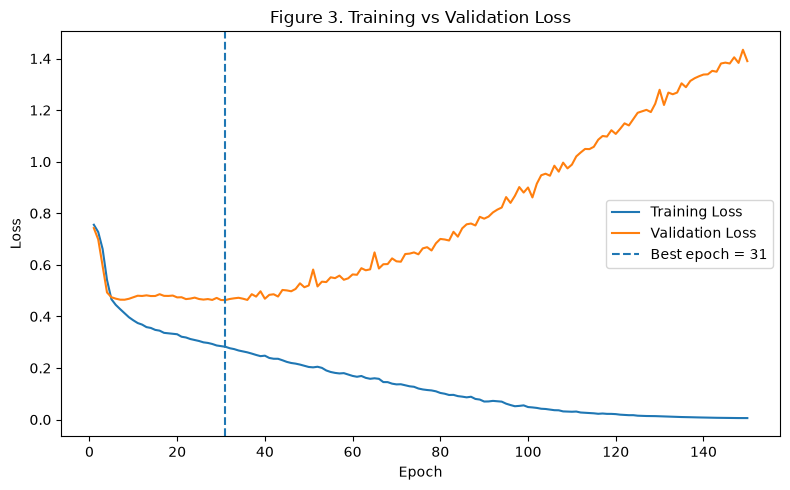

In [21]:
epochs_axis = np.arange(1, MAX_EPOCHS + 1)
plt.figure(figsize=(8,5))
plt.plot(epochs_axis, train_losses, label="Training Loss")
plt.plot(epochs_axis, val_losses, label="Validation Loss")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Figure 3. Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()

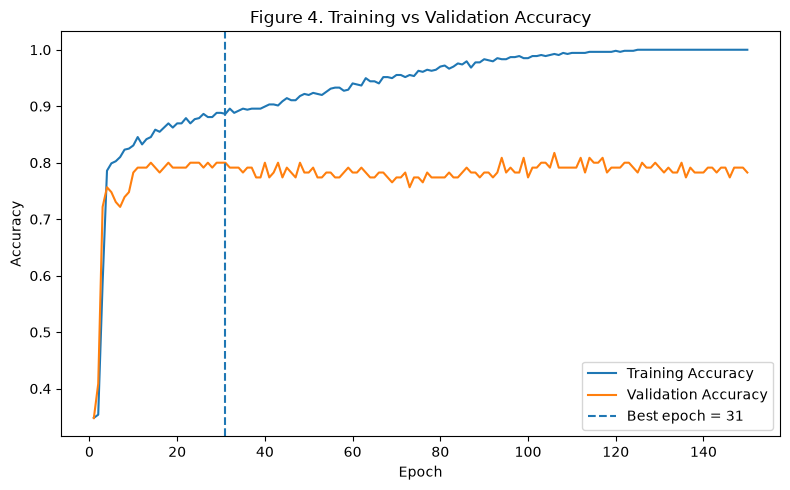

In [22]:
plt.figure(figsize=(8,5))
plt.plot(epochs_axis, train_accs, label="Training Accuracy")
plt.plot(epochs_axis, val_accs, label="Validation Accuracy")
plt.axvline(best_epoch, linestyle="--", label=f"Best epoch = {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Figure 4. Training vs Validation Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# 13. Final Retraining on Train + Validation

At this point the model-development choices are fixed:

- KNN: `BEST_K`
- MLP: number of final epochs = `best_epoch`
- Random Forest configuration fixed
- Logistic Regression configuration fixed

Now Train + Validation are merged. All **four final models** are retrained using the same 85% development data, and the held-out 15% Test set is used only for final metrics.

In [23]:
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_scaler = StandardScaler()
X_trainval_scaled = final_scaler.fit_transform(X_trainval)
X_test_scaled = final_scaler.transform(X_test)

print("Final training data:", X_trainval.shape)
print("Held-out test data :", X_test.shape)

Final training data: (652, 8)
Held-out test data : (116, 8)


## 13.1 Final Traditional ML Models

In [24]:
final_rows = []
final_predictions = {}
final_probabilities = {}
fit_times = {}
inference_times = {}

# Logistic Regression
final_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
t0 = time.perf_counter(); final_lr.fit(X_trainval_scaled, y_trainval); fit_times["Logistic Regression"] = time.perf_counter()-t0
t0 = time.perf_counter(); lr_pred = final_lr.predict(X_test_scaled); inference_times["Logistic Regression"]=(time.perf_counter()-t0)*1000
lr_prob = final_lr.predict_proba(X_test_scaled)[:,1]
final_predictions["Logistic Regression"] = lr_pred
final_probabilities["Logistic Regression"] = lr_prob
final_rows.append(classification_metrics("Logistic Regression", y_test, lr_pred, lr_prob))

# KNN
knn_name = f"KNN (k={BEST_K})"
final_knn = KNeighborsClassifier(n_neighbors=BEST_K)
t0 = time.perf_counter(); final_knn.fit(X_trainval_scaled, y_trainval); fit_times[knn_name] = time.perf_counter()-t0
t0 = time.perf_counter(); knn_pred = final_knn.predict(X_test_scaled); inference_times[knn_name]=(time.perf_counter()-t0)*1000
knn_prob = final_knn.predict_proba(X_test_scaled)[:,1]
final_predictions[knn_name] = knn_pred
final_probabilities[knn_name] = knn_prob
final_rows.append(classification_metrics(knn_name, y_test, knn_pred, knn_prob))

# Random Forest
final_rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced")
t0 = time.perf_counter(); final_rf.fit(X_trainval, y_trainval); fit_times["Random Forest"] = time.perf_counter()-t0
t0 = time.perf_counter(); rf_pred = final_rf.predict(X_test); inference_times["Random Forest"]=(time.perf_counter()-t0)*1000
rf_prob = final_rf.predict_proba(X_test)[:,1]
final_predictions["Random Forest"] = rf_pred
final_probabilities["Random Forest"] = rf_prob
final_rows.append(classification_metrics("Random Forest", y_test, rf_pred, rf_prob))

## 13.2 Final 5-Layer MLP

The final MLP is reinitialized and trained on Train + Validation for exactly the number of epochs selected during development.

In [25]:
# Reset seed for reproducible final MLP initialization
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

final_mlp = FiveLayerMLP(input_dim=X_trainval.shape[1]).to(DEVICE)
final_criterion = nn.BCEWithLogitsLoss()
final_optimizer = torch.optim.Adam(final_mlp.parameters(), lr=LEARNING_RATE)

trainval_ds = make_tensor_dataset(X_trainval_scaled, y_trainval)
final_g = torch.Generator(); final_g.manual_seed(RANDOM_STATE)
trainval_loader = DataLoader(trainval_ds, batch_size=BATCH_SIZE, shuffle=True, generator=final_g)

t0 = time.perf_counter()
for epoch in range(1, best_epoch + 1):
    final_mlp.train()
    for xb, yb in trainval_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        final_optimizer.zero_grad()
        logits = final_mlp(xb)
        loss = final_criterion(logits, yb)
        loss.backward()
        final_optimizer.step()
fit_times["5-Layer MLP"] = time.perf_counter() - t0

# Final test inference
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(DEVICE)
t0 = time.perf_counter()
final_mlp.eval()
with torch.no_grad():
    final_logits = final_mlp(X_test_tensor)
    final_prob = torch.sigmoid(final_logits).cpu().numpy().ravel()
    final_pred = (final_prob >= 0.5).astype(int)
inference_times["5-Layer MLP"] = (time.perf_counter()-t0)*1000

final_predictions["5-Layer MLP"] = final_pred
final_probabilities["5-Layer MLP"] = final_prob
final_rows.append(classification_metrics("5-Layer MLP", y_test, final_pred, final_prob))

# 14. Metrics — Definitions and Report Formulas

Let Diabetes (`1`) be the positive class.

### Accuracy
$$
\boxed{Accuracy=\frac{TP+TN}{TP+TN+FP+FN}}
$$
Overall proportion of correct predictions.

### Precision
$$
\boxed{Precision=\frac{TP}{TP+FP}}
$$
Among patients predicted as Diabetes, how many are truly Diabetes?

### Recall
$$
\boxed{Recall=\frac{TP}{TP+FN}}
$$
Among truly diabetic patients, how many are detected? In a disease-screening context this is especially important because low recall means more false negatives.

### F1-score
$$
\boxed{F1=2\frac{Precision\times Recall}{Precision+Recall}}
$$
Harmonic balance between Precision and Recall.

### ROC-AUC
ROC considers True Positive Rate versus False Positive Rate across thresholds. AUC summarizes the model's ability to rank/separate positive and negative cases across those thresholds.

# 15. Final Metrics Comparison — ML vs DL

In [26]:
comparison = pd.DataFrame(final_rows)
comparison["Fit_Time_s"] = comparison["Model"].map(fit_times)
comparison["Inference_Time_ms"] = comparison["Model"].map(inference_times)
comparison = comparison.sort_values("F1", ascending=False).reset_index(drop=True)
comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Fit_Time_s,Inference_Time_ms
0,5-Layer MLP,0.8966,0.9394,0.7561,0.8378,0.9389,1.6756,1.0065
1,Random Forest,0.8879,0.8684,0.8049,0.8354,0.9663,0.9373,56.4468
2,KNN (k=7),0.8190,0.8125,0.6341,0.7123,0.8738,0.0031,4.8732
3,Logistic Regression,0.7845,0.7353,0.6098,0.6667,0.8995,0.0099,0.8472


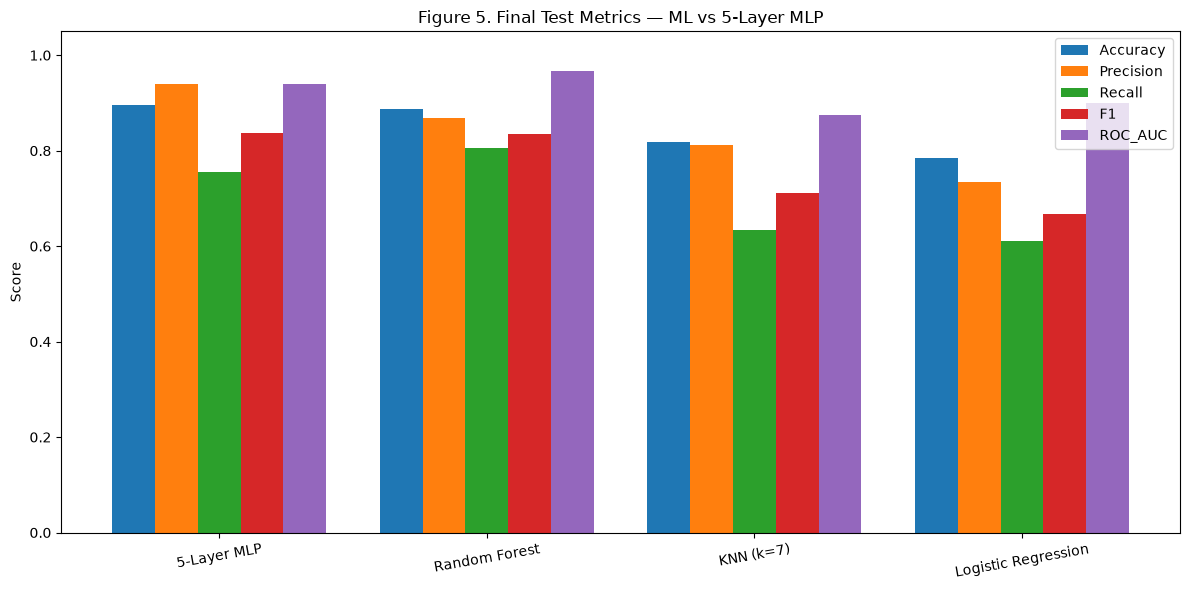

In [27]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
plot_df = comparison.set_index("Model")[metric_cols]

x = np.arange(len(plot_df.index))
width = 0.16

plt.figure(figsize=(12,6))
for i, metric in enumerate(metric_cols):
    plt.bar(x + (i-2)*width, plot_df[metric].values, width=width, label=metric)

plt.xticks(x, plot_df.index, rotation=10)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Figure 5. Final Test Metrics — ML vs 5-Layer MLP")
plt.legend()
plt.tight_layout()
plt.show()

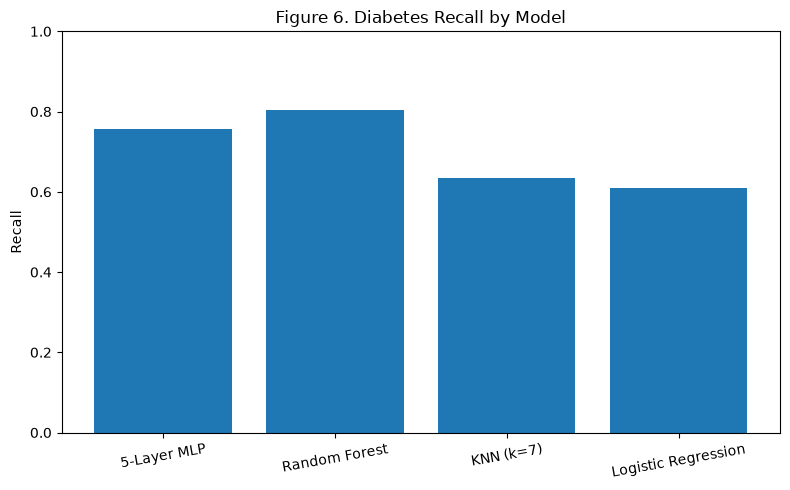

In [28]:
plt.figure(figsize=(8,5))
plt.bar(comparison["Model"], comparison["Recall"])
plt.ylim(0,1)
plt.ylabel("Recall")
plt.title("Figure 6. Diabetes Recall by Model")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# 16. Confusion Matrices

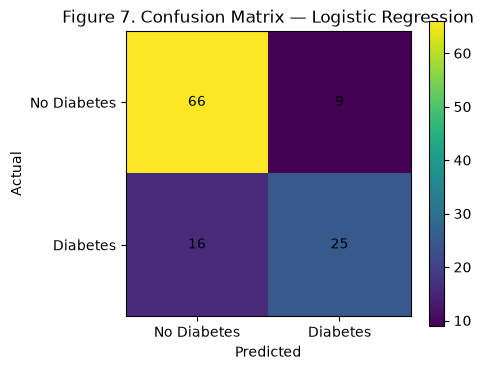

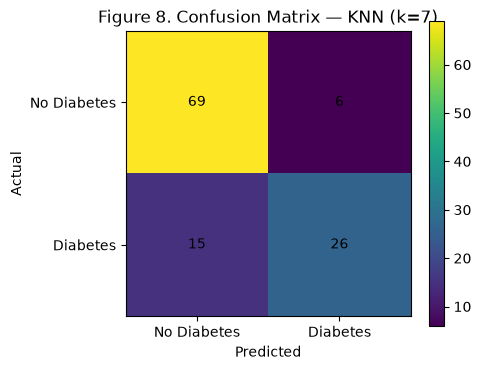

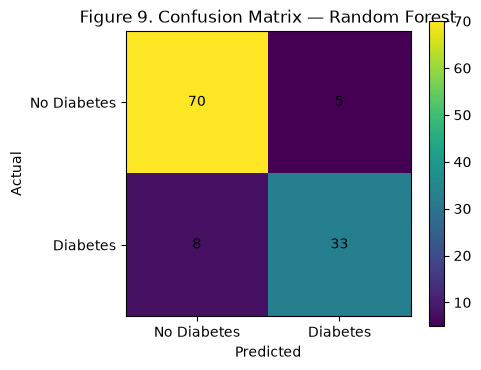

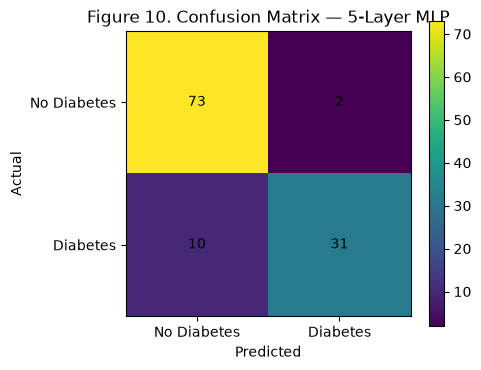

In [29]:
def plot_confusion(y_true, y_pred, model_name, figure_no):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    plt.imshow(cm)
    plt.xticks([0,1], ["No Diabetes", "Diabetes"])
    plt.yticks([0,1], ["No Diabetes", "Diabetes"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Figure {figure_no}. Confusion Matrix — {model_name}")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j], ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    return cm

figure_no = 7
confusion_tables = {}
for model_name in ["Logistic Regression", knn_name, "Random Forest", "5-Layer MLP"]:
    confusion_tables[model_name] = plot_confusion(y_test, final_predictions[model_name], model_name, figure_no)
    figure_no += 1

# 17. ROC Curves

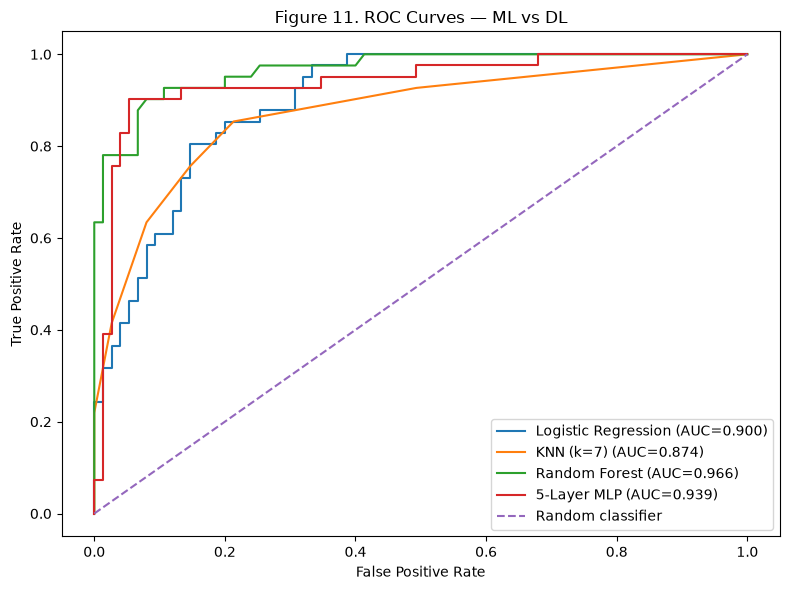

In [30]:
plt.figure(figsize=(8,6))
for model_name, probs in final_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Figure 11. ROC Curves — ML vs DL")
plt.legend()
plt.tight_layout()
plt.show()

# 18. Computational Cost

In [31]:
cost_df = comparison[["Model", "Fit_Time_s", "Inference_Time_ms"]].copy()
cost_df.round(4)

,Model,Fit_Time_s,Inference_Time_ms
0,5-Layer MLP,1.6756,1.0065
1,Random Forest,0.9373,56.4468
2,KNN (k=7),0.0031,4.8732
3,Logistic Regression,0.0099,0.8472


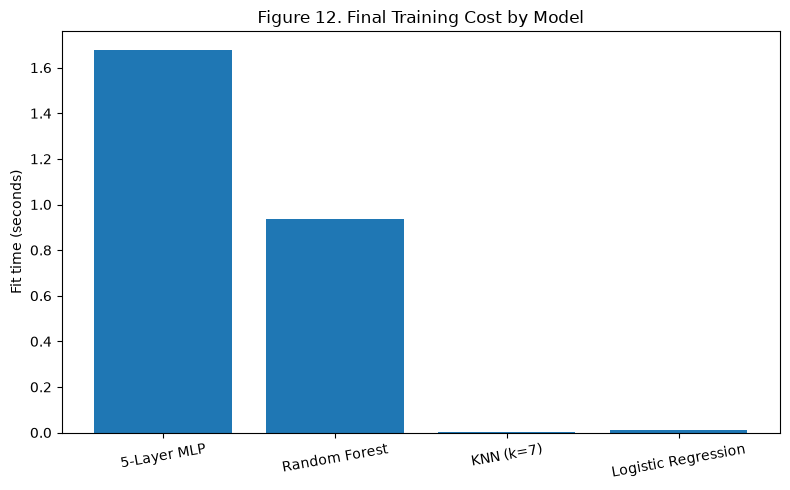

In [32]:
plt.figure(figsize=(8,5))
plt.bar(cost_df["Model"], cost_df["Fit_Time_s"])
plt.ylabel("Fit time (seconds)")
plt.title("Figure 12. Final Training Cost by Model")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

# 19. Traditional ML Interpretability — Random Forest Feature Importance

Feature importance is useful for model interpretation, but it should **not** be interpreted as causal evidence.

In [33]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_rf.feature_importances_
}).sort_values("Importance", ascending=False)
importance_df

,Feature,Importance
4,Insulin,0.363015
1,Glucose,0.149931
3,SkinThickness,0.146319
5,BMI,0.092438
7,Age,0.083600
6,DiabetesPedigreeFunction,0.071197
0,Pregnancies,0.047104
2,BloodPressure,0.046395


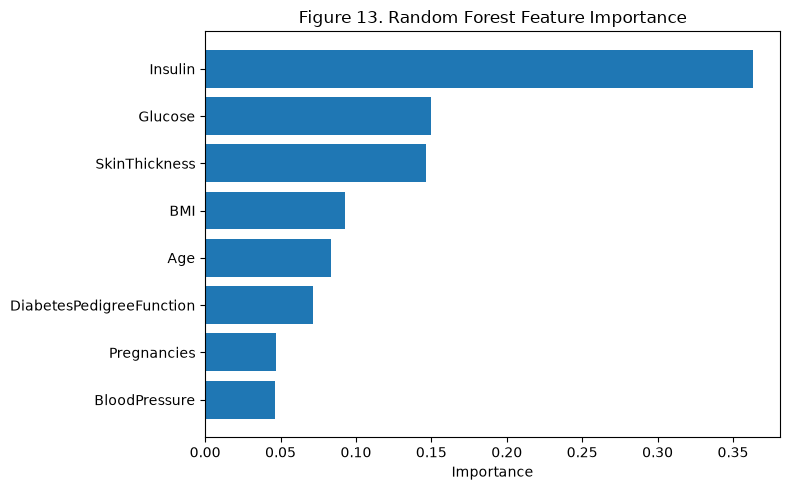

In [34]:
plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Figure 13. Random Forest Feature Importance")
plt.tight_layout()
plt.show()

# 20. Deep Learning Representation Analysis

The Assignment 03 material emphasizes:

$$
\boxed{X \rightarrow H_1 \rightarrow H_2 \rightarrow \cdots \rightarrow \hat{y}}
$$

The hidden vector is a **learned representation** rather than a manually named medical feature.

For our model:

$$
8 \rightarrow 64 \rightarrow 32 \rightarrow 16 \rightarrow \boxed{8\text{-dimensional }H_4} \rightarrow 1
$$

To visualize this idea, PCA is used only for plotting the test-set representation in two dimensions.

Original standardized test shape: (116, 8)
Learned H4 representation shape : (116, 8)


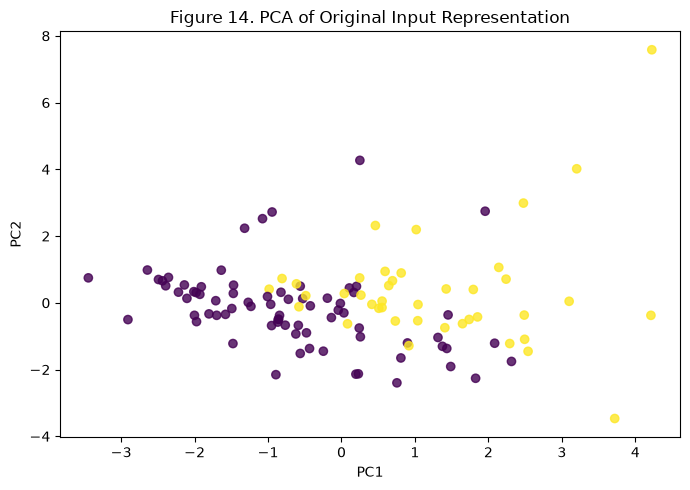

In [35]:
final_mlp.eval()
with torch.no_grad():
    h4 = final_mlp.representation(X_test_tensor).cpu().numpy()

print("Original standardized test shape:", X_test_scaled.shape)
print("Learned H4 representation shape :", h4.shape)

pca_raw = PCA(n_components=2, random_state=RANDOM_STATE)
raw_2d = pca_raw.fit_transform(X_test_scaled)

plt.figure(figsize=(7,5))
plt.scatter(raw_2d[:,0], raw_2d[:,1], c=y_test.to_numpy(), alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Figure 14. PCA of Original Input Representation")
plt.tight_layout()
plt.show()

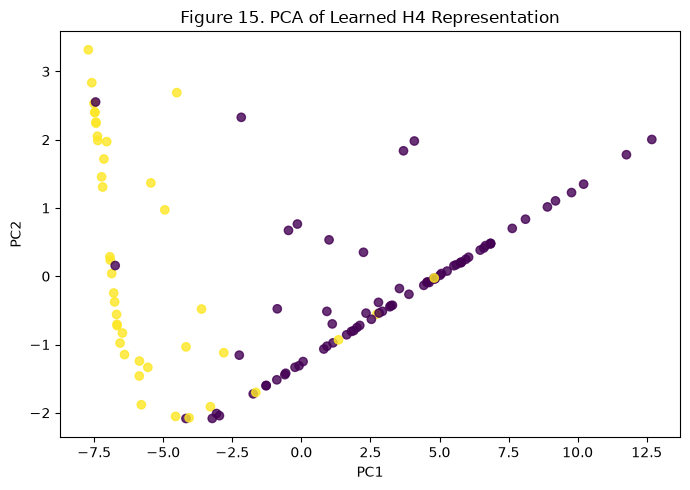

In [36]:
pca_hidden = PCA(n_components=2, random_state=RANDOM_STATE)
hidden_2d = pca_hidden.fit_transform(h4)

plt.figure(figsize=(7,5))
plt.scatter(hidden_2d[:,0], hidden_2d[:,1], c=y_test.to_numpy(), alpha=0.8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Figure 15. PCA of Learned H4 Representation")
plt.tight_layout()
plt.show()

# 21. Scientific Comparison — Beyond Accuracy

The Assignment 03 material explicitly warns that **better model ≠ higher accuracy only**. Use the final report to discuss both predictive quality and model characteristics.

In [37]:
characteristics = pd.DataFrame([
    ["Logistic Regression", "Prepared", "Linear", "Low", "High", "Low"],
    [knn_name, "Prepared", "Nonlinear / local", "Low", "Medium", "Low fit / higher prediction cost"],
    ["Random Forest", "Prepared", "Nonlinear", "Medium", "Medium", "Medium"],
    ["5-Layer MLP", "Learned representations", "Nonlinear", "High (3329 trainable params)", "Lower", "Higher"]
], columns=["Model", "Representation", "Nonlinearity", "Complexity", "Interpretability", "Training Cost"])
characteristics

,Model,Representation,Nonlinearity,Complexity,Interpretability,Training Cost
0,Logistic Regression,Prepared,Linear,Low,High,Low
1,KNN (k=7),Prepared,Nonlinear / local,Low,Medium,Low fit / higher prediction cost
2,Random Forest,Prepared,Nonlinear,Medium,Medium,Medium
3,5-Layer MLP,Learned representations,Nonlinear,High (3329 trainable params),Lower,Higher


# 22. Report-Ready Discussion Checklist

Use the generated tables/figures to answer:

1. Which model has the highest **Accuracy**?
2. Which has the highest **Precision**?
3. Which has the highest **Recall**? Why is Recall important for Diabetes?
4. Which has the highest **F1-score**?
5. Which has the highest **ROC-AUC**?
6. What do the confusion matrices reveal about **False Negatives**?
7. Does the MLP training curve show underfitting, good fit, or overfitting?
8. Does the 5-layer MLP improve test generalization compared with traditional ML?
9. How many parameters does the MLP introduce (3329)?
10. Is any performance improvement practically meaningful relative to training cost and interpretability?
11. What changes between the original input representation and the learned hidden representation?

### Suggested conclusion pattern

> Four models were evaluated on the same held-out test set. ______ achieved the strongest overall predictive performance according to ______. The 5-layer MLP learned a hierarchy of hidden representations using successive linear transformations and ReLU nonlinearities. However, model selection should consider not only predictive metrics but also false negatives, generalization, number of parameters, computational cost, and interpretability.

# 23. Save Results and Models

The Assignment 03 slide lists a saved model and experimental results among the deliverables.

In [38]:
comparison.to_csv("diabetes_model_comparison.csv", index=False)
joblib.dump(final_scaler, "diabetes_standard_scaler.pkl")
joblib.dump(final_lr, "diabetes_logistic_regression.pkl")
joblib.dump(final_knn, "diabetes_knn.pkl")
joblib.dump(final_rf, "diabetes_random_forest.pkl")

torch.save({
    "model_state_dict": final_mlp.state_dict(),
    "architecture": [8, 64, 32, 16, 8, 1],
    "input_dim": X_trainval.shape[1],
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "selected_epochs": best_epoch,
    "trainable_parameters": total_params
}, "diabetes_5_layer_mlp.pth")

print("Saved comparison table and final models.")

Saved comparison table and final models.


# Appendix A — Optional Controlled Experiments from the Teacher Assignment Slide

The Assignment 03 slide also asks for controlled MLP experiments (baseline, deeper network, and optimization comparison). Your current assignment plan specifically requires a 5-layer DL model, so the 5-layer MLP above is the main submitted model.

If the lecturer also enforces the slide's controlled-experiment requirement, add experiments such as:

- Baseline MLP: $8\rightarrow64\rightarrow1$
- Deeper MLP: $8\rightarrow64\rightarrow32\rightarrow1$
- Main 5-layer MLP: $8\rightarrow64\rightarrow32\rightarrow16\rightarrow8\rightarrow1$
- Optimization experiment: compare Adam learning rates `0.001` vs `0.01`, or Adam vs SGD.

For every experiment report:
- architecture
- parameter count
- training configuration
- training/validation curves
- test metrics
- interpretation

This appendix is intentionally left as an extension so the main ML-vs-DL comparison remains focused.